# **HCC1806 SmartSeq**

# **Introduction**:

In this file, we finalize our investigation by implementing different **Supervised Learning** models for hypoxia prediction, performing a cross-cellline and cross-technology evaluation of our models, and testing the best performing model on **unseen data**.

## **Structure of the file**:

1. **Introduction**
    * Structure of the file
    * Python Libraries
2. **Supervised Learning**
    * Test/Train Split
    * Training and Evaluating Models
    * Best Learning Model
3. **Predictions (Testing on Unseen Data)**
4. **Pathway Analysis**
    * Selecting most important features
    * Over Representation Analysis (ORA)

## **Python Libraries**

In [75]:
import sys
import sklearn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(color_codes=True)
import gseapy as gp # gene set enrichment analysis
from gseapy import dotplot, barplot
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV 
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import VotingClassifier
from joblib import dump

# **Supervised Learning**

We begin the Supervised Learning section of this investigation by training, testing, and evaluating different supervised classification models in an attempt to predict hypoxia in tumor cells. 

All four datasets explored the same five supervised learning approaches, the reasoning behind this choice will be further explained later on. However, in this notebook you will find the models that were trained with reference to the HCC1806 SmartSeq dataset.

Afterwards, we will run each of the five models on the other 3 other datasets (HCC1806 DropSeq, MCF07 SmartSeq, and MCF07 DropSeq) and evaluate the models based on their performance across all datasets with reference to several scoring metrics as to ensure a holistic analysis.

## **Train/Test Split**

First, we import the HCC1807 SmartSeq dataset, which has already been filtered, normalized and contains only the 3000 most variable genes.

In [2]:
dataset = pd.read_csv("/Users/bianca/Desktop/HCC1806_SmartS_Filtered_Normalised_3000_Data_train.txt",delimiter="\ ",engine='python',index_col=0 )
dataset.head()

,"""output.STAR.PCRPlate1G12_Normoxia_S32_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1G3_Hypoxia_S7_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1G4_Hypoxia_S107_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1G7_Normoxia_S118_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1G8_Normoxia_S19_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1G9_Normoxia_S121_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1H1_Hypoxia_S103_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate1H2_Hypoxia_S3_Aligned.sortedByCoord.out.bam""",...,"""output.STAR.PCRPlate4G12_Normoxia_S243_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G1_Hypoxia_S193_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G2_Hypoxia_S198_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G6_Hypoxia_S232_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4G7_Normoxia_S204_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H10_Normoxia_S210_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H11_Normoxia_S214_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H7_Normoxia_S205_Aligned.sortedByCoord.out.bam""","""output.STAR.PCRPlate4H9_Normoxia_S236_Aligned.sortedByCoord.out.bam"""
"""DDIT4""",0,8739,13098,2880,7777,208,750,127,10313,13523,...,341,5545,5757,8337,2579,79,167,10186,238,60
"""ANGPTL4""",48,2101,14032,356,5661,0,0,0,850,10110,...,10,2085,698,2383,65,5,1,3147,41,0
"""CALML5""",0,55,0,0,4383,1902,0,0,0,0,...,0,1587,0,0,0,0,0,0,2867,0
"""KRT14""",321,96,0,6211,0,0,5050,462,2127,0,...,0,0,3077,529,156,2098,27,149,814,7
"""CCNB1""",298,1824,1616,3,145,378,66,58,605,1444,...,204,26,50,588,411,554,3585,1012,2207,477


We transpose the original DataFrame to have the cells in the rows and the genes in the columns so as to facilitate future analysis. We will also remove the quotation marks in the names of the features and the samples to simplify our analysis. 

In [3]:
def remove_double_quotes(word):
    return word.replace('"', '')
dataset = dataset.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in dataset.columns})
dataset = dataset.T
dataset = dataset.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in dataset.columns})


Checking the distribution of the target value in this dataset:

In [4]:
dataset['label'] = dataset.index.to_series().apply(lambda x: 'Normoxia' if 'Norm' in x else 'Hypoxia')
dataset["label"].value_counts() 

label
Hypoxia     97
Normoxia    85
Name: count, dtype: int64

We move on by splitting the dataset into a training set (80%) and an internal test set (20%).  We use a stratified split, meaning both sets preserve the original 53/47 Hypoxia/Normoxia ratio. Without stratification, one set could end up with a very different class balance purely by chance, making evaluation unreliable.

In [ ]:
dataset['label'] = dataset.index.to_series().apply(lambda x: 0 if 'Norm' in x else 1)

X = dataset.drop("label", axis = 1)
y = dataset["label"]

X_train, X_test, Y_train, Y_test = train_test_split(X, y,test_size=0.2, stratify=y, random_state=123)
X_train.to_csv('/Users/bianca/Desktop/X_train.csv')
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)
X_train

(145, 3000) (145,) (37, 3000) (37,)


,DDIT4,ANGPTL4,CALML5,KRT14,CCNB1,IGFBP3,AKR1C2,KRT6A,NDRG1,KRT4,...,MST1R,ZYG11A,NRG1,RBMS3,VCPIP1,LINC02693,OR8B9P,NEAT1,ZDHHC23,ODAD2
output.STAR.PCRPlate4C1_Hypoxia_S222_Aligned.sortedByCoord.out.bam,4510,902,0,232,1,1,2447,651,309,0,...,0,0,49,0,17,0,0,156,0,0
output.STAR.PCRPlate3G12_Normoxia_S219_Aligned.sortedByCoord.out.bam,20,0,1331,4680,14,3296,743,6375,20,3335,...,113,0,12,0,83,53,0,43,0,0
output.STAR.PCRPlate2G9_Normoxia_S56_Aligned.sortedByCoord.out.bam,337,41,905,528,509,2472,2027,9584,8,1253,...,0,0,10,0,0,34,0,84,0,0
output.STAR.PCRPlate3F3_Hypoxia_S170_Aligned.sortedByCoord.out.bam,11968,274,0,2,442,78,17,939,558,0,...,204,4,778,0,147,152,0,1,23,0
output.STAR.PCRPlate3E2_Hypoxia_S65_Aligned.sortedByCoord.out.bam,8143,2291,0,63,390,0,21,258,1617,0,...,316,0,0,9,0,90,3,94,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
output.STAR.PCRPlate4B10_Normoxia_S238_Aligned.sortedByCoord.out.bam,247,0,0,384,484,230,2591,5924,21,2538,...,60,0,80,0,57,0,0,23,0,0
output.STAR.PCRPlate3G6_Hypoxia_S181_Aligned.sortedByCoord.out.bam,4835,1076,0,0,17,792,837,809,662,0,...,29,9,110,0,53,21,0,549,41,0
output.STAR.PCRPlate2F2_Hypoxia_S33_Aligned.sortedByCoord.out.bam,2872,935,0,0,4,3668,12,230,458,0,...,186,1,166,0,0,162,0,35,0,0
output.STAR.PCRPlate1H9_Normoxia_S122_Aligned.sortedByCoord.out.bam,404,32,0,1893,2796,27,1496,626,81,0,...,0,6,201,0,239,160,0,30,23,0


## **Training and Evaluating Models**

Moving on to actually training and evaluating our models, we define two functions to accomplish each task.

*train_model*: Function dedicated to training each supervised learning model using the training set (X_train and Y_train). Runs hyperparameter tuning using GridSearchCV combined with a 5-Fold Cross-Validation in order to identify the best combination of parameters for each classifier. Also, it uses "accuracy" as the scoring metric given how the dataset is balanced. It returns best model and a list of the hyperparameters it used. 

*evaluate_model*: Function dedicated to evaluating the performance of each model on the test set (X_test, Y_test). Generates predictions and computes several scoring metrics: accuracy, precision, recall, F1-score, AUC score, and the confusion matrix. These metrics allow us to holistically assess the predictive performance of each model as to later compare the different supervised learning approaches.

Finally, we define a function used to evaluate the performance of the trained models on the test set. This function generates predictions and, with respect to the actual label, computes several evaluation metrics: accuracy, precision, recall, F1-score, AUC score, and the confusion matrix. These metrics allow us to holistically assess the predictive performance of each model as to later compare the different supervised learning approaches.

In [50]:
def train_model(model, parameter_grid, X_train, Y_train):
    grid = GridSearchCV(model,parameter_grid,cv=5,scoring="accuracy",verbose=1,n_jobs=-1)    
    grid.fit(X_train, Y_train)

    best_model = grid.best_estimator_
    best_parameters = grid.best_params_
    return best_model, best_parameters

def evaluate_model(best_model, X_test, Y_test, name):
    y_pred = best_model.predict(X_test)
    y_prob = best_model.predict_proba(X_test)[:, 1]
    scores = {"model": name,
              "accuracy": accuracy_score(Y_test, y_pred),
              "precision": precision_score(Y_test, y_pred),
              "recall": recall_score(Y_test, y_pred),
              "f1": f1_score(Y_test, y_pred),
              "auc": roc_auc_score(Y_test, y_prob),
              "confusion_matrix": confusion_matrix(Y_test, y_pred)}
    return scores

Following, we define a dictionary containing all of the supervised models that we are considering in our analysis together with the corresponding hyperparameters that we test. The models considered were chosen based on their diverse strengths, the nature of the task and characteristics of the dataset. 

1. **Logistic Regression**: As it is a fundamental method for binary classification, it is a simpler but highly interpretable model. 
    
    *Penalty Type* - Lasso vs Ridge Regression: determing whether sparse feature selection or smooth coefficient shrinkage performs better.
    
    *Regularization Parameter*: to determine the best balance between underfitting and overfitting.
    
    *Solver* - Liblinear vs Saga: optimisation algorithms can vary in convergence speed and performance depending on the dataset and penalty type.

2. **Random Forest**: Versatile and robust to overfitting as well as  highly able of handling nonlinear relationships and high-dimensional datasets.
    
    *Number of Estimators*: More trees can improve stability and predictive performance.
    
    *Maximum Tree Depth*: Influences model complexity and risk of overfitting.
    
    *Minimum Samples per Leaf*: to prevent overly specific splits and improve generalisation.

3. **K-Nearest Neighbors (kNN)**: Especially good at dealing with complex decision boundaries. 
    
    *Number of Neighbors*: Larger value may lead to better performance but too large and the points aren't "neighbors" anymore.
    
    *Weights* - Uniform vs Distance: determine whether all neighbors contributing equally or closer neighbours have greater influence on predictions performs better.
    
    *Metric* - Euclidean vs Manhattan: find the best distance calculation method to identify nearest neighbours.

4. **Support Vector Machiness (SVM)**: Common for classification, excels at handling high-dimensional data and finding complex, non-linear decision boundaries.
    
    *Kernel* - RBF vs Sigmoid vs Poly vs Linear: determine the type of decision boundary used to separate classes.
    
    *Gamma*: Controls how far the influence of a single training example reaches in nonlinear kernels.
    
    *Regularization Parameter*: to determine the best balance between underfitting and overfitting.


In [53]:
models = {"logistic_regression": (LogisticRegression(max_iter=5000, random_state=42), {"penalty": ["l1", "l2"],
                                                                      "C": [0.001, 0.01, 0.1, 1, 10, 100, 1000],
                                                                      "solver": ["liblinear", "saga"]} ),
    
          "random_forest": (RandomForestClassifier(random_state=42), {"n_estimators": [10, 25, 50, 75, 100, 150, 200, 250],
                                                                      "max_depth": [None, 5, 10, 15, 20],
                                                                      "min_samples_leaf": [1, 2, 4, 6, 8]} ),
    
          "knn": (KNeighborsClassifier(), {"n_neighbors": range(1, 30),
                                           "weights": ["uniform", "distance"],
                                           "metric": ["euclidean", "manhattan"]}),
    
          "svm": (SVC(probability=True, random_state=42),{"kernel": ["rbf", "sigmoid", "poly", "linear"],
                                                          "gamma": ["scale", 0.1, 0.01, 0.001],
                                                          "C": [0.1, 1, 10, 100]})}

We proceed by training each model and storing the best performing model in the "best_models" dictionary along its optimal hyperparameters.

In [54]:
best_models = {}
for name, (model, parameter_grid) in models.items():
    best_model, best_parameters = train_model(model, parameter_grid, X_train, Y_train)
    best_models[name] = (best_model, best_parameters)

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Fitting 5 folds for each of 200 candidates, totalling 1000 fits
Fitting 5 folds for each of 116 candidates, totalling 580 fits
Fitting 5 folds for each of 64 candidates, totalling 320 fits


To see what were indeed the best models and their respective hyperparameters:

In [55]:
def print_best_parameters(best_models):
    for name, (best_model, best_parameters) in best_models.items():
        print(f"\n{name.upper()}")
        for param, value in best_parameters.items():
            print(f"{param}: {value}")
print_best_parameters(best_models)


LOGISTIC_REGRESSION
C: 1
penalty: l1
solver: liblinear

RANDOM_FOREST
max_depth: None
min_samples_leaf: 1
n_estimators: 50

KNN
metric: euclidean
n_neighbors: 3
weights: uniform

SVM
C: 10
gamma: scale
kernel: rbf


Now, vizualizing each model's performance across all scoring metrics.

In [56]:
model_scores = []
for name, (best_model, parameter_grid) in best_models.items():
    scores = evaluate_model(best_model, X_test, Y_test, name)
    model_scores.append(scores)
scores_df = pd.DataFrame(model_scores)
scores_df


,model,accuracy,precision,recall,f1,auc,confusion_matrix
0,logistic_regression,1.000000,1.000000,1.00,1.000000,1.000000,"[[17, 0], [0, 20]]"
1,random_forest,1.000000,1.000000,1.00,1.000000,1.000000,"[[17, 0], [0, 20]]"
2,knn,0.972973,1.000000,0.95,0.974359,0.973529,"[[17, 0], [1, 19]]"
3,svm,0.972973,0.952381,1.00,0.975610,0.997059,"[[16, 1], [0, 20]]"


Logistic Regression and Random Forest achieved perfect performance across all evaluation metrics, correctly classifying all samples in the test set. kNN and SVM also performed strongly with accuracies of 97.3%, although each produced one misclassification, resulting in slightly lower recall or precision compared with the top-performing models.

In addition to the four models already trained, we also decided to create an Ensemble Model that combined predictions from our four models above to create a more accurate, robust, and stable final prediction.
For this task we used a VotingClassifier with soft voting so that each model's contribution to the final prediction was based on their individual predictive performance. More especifically, we used their F1-scores as weights as it can provide a balanced measure between precision and recall.

In [57]:
estimators = [ (name, best_model) for name, (best_model, best_parameters) in best_models.items()]
weights = scores_df.set_index("model").loc[[name for name, model in estimators],"f1"].tolist()

ensemble = VotingClassifier(estimators=estimators,voting="soft",weights=weights)
ensemble.fit(X_train, Y_train)
ensemble_scores = evaluate_model(ensemble,X_test,Y_test,"ensemble")
scores_df.loc[len(scores_df)] = ensemble_scores
scores_df["dataset"] = "HCC1806 SmartSeq (Internal)"
best_models["ensemble"] = (ensemble, {"weights": weights})
scores_df


,model,accuracy,precision,recall,f1,auc,confusion_matrix,dataset
0,logistic_regression,1.000000,1.000000,1.00,1.000000,1.000000,"[[17, 0], [0, 20]]",HCC1806 SmartSeq (Internal)
1,random_forest,1.000000,1.000000,1.00,1.000000,1.000000,"[[17, 0], [0, 20]]",HCC1806 SmartSeq (Internal)
2,knn,0.972973,1.000000,0.95,0.974359,0.973529,"[[17, 0], [1, 19]]",HCC1806 SmartSeq (Internal)
3,svm,0.972973,0.952381,1.00,0.975610,0.997059,"[[16, 1], [0, 20]]",HCC1806 SmartSeq (Internal)
4,ensemble,1.000000,1.000000,1.00,1.000000,1.000000,"[[17, 0], [0, 20]]",HCC1806 SmartSeq (Internal)


The Ensemble method achieved perfect performance across all evaluation metrics. Thus, if we were to hollistically rank our five models based on their performance on the HCC1807 SmartSeq Dataset, we would have a three-way tie for first place as Logistic Regression, Random Forests, and Ensemble correctly classified all samples in the test set. 

## **Vizualizing Model Performance**

We proceed with graphing the evalutation metrics for each model as to better vizualize their respective performance's and facilitate interpretation.

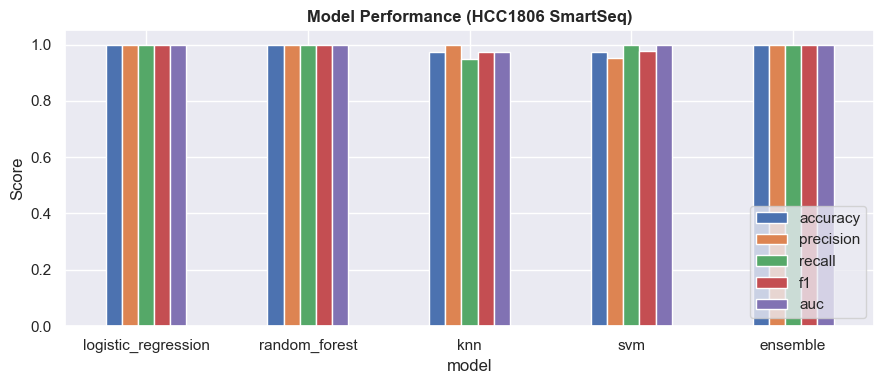

In [58]:
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc']
plot_df = scores_df[['model'] + metrics].set_index('model')

plot_df.plot(kind='bar', figsize=(9, 4))
plt.title("Model Performance (HCC1806 SmartSeq)", weight = "bold")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Following, we plot the confusion matrices as to better vizualize and intepret the correctness of the predictions of each model.

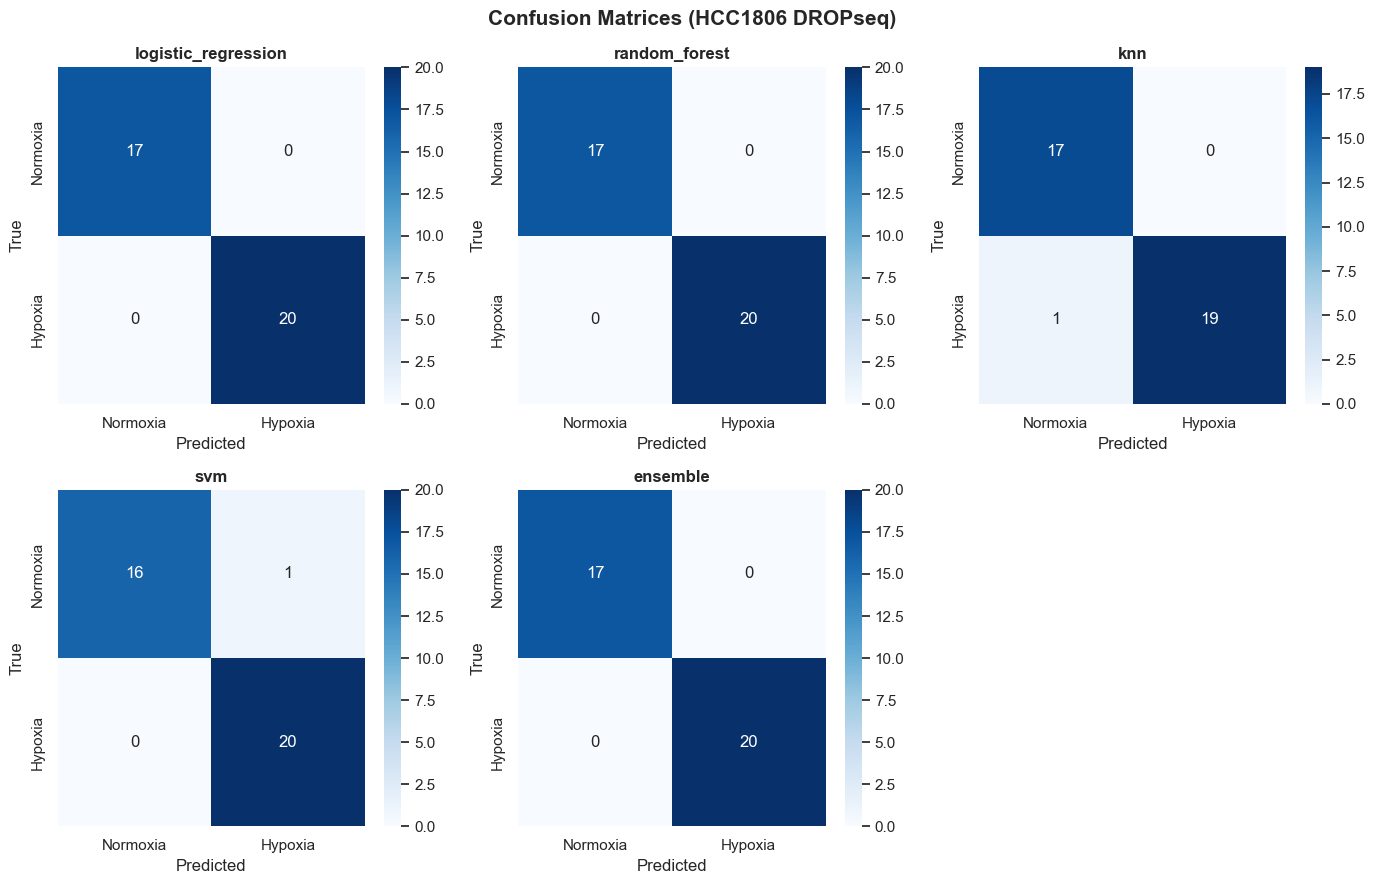

In [59]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()
for i, (name, model) in enumerate(best_models.items()):
    cm = scores_df.set_index("model").loc[name, "confusion_matrix"]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Normoxia', 'Hypoxia'],
                yticklabels=['Normoxia', 'Hypoxia'])
    axes[i].set_title(name, weight = "bold" )
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("True")

axes[-1].set_visible(False)
plt.suptitle("Confusion Matrices (HCC1806 DROPseq)", fontsize=15, weight = "bold")
plt.tight_layout()
plt.show()

## **Best Learning Model**

To truly assess the predictive performance of our five models, we run our models trained with the HCC1806 SmartSeq dataset on all of the other cell lines and sequencing technologies. This allows us to evaluate the generalization ability of the models beyond the datasets on which they were originally trained.

In [60]:
df_mcf07_SS = pd.read_csv("/Users/bianca/Desktop/MCF7_SmartS_Filtered_Normalised_3000_Data_train.txt", delimiter="\ ", engine="python", index_col=0)
df_hcc1806_DS = pd.read_csv("/Users/bianca/Desktop/HCC1806_Filtered_Normalised_3000_Data_train.txt", delimiter="\ ", engine="python", index_col=0)
df_mcf07_DS = pd.read_csv("/Users/bianca/Desktop/MCF7_Filtered_Normalised_3000_Data_train.txt", delimiter="\ ", engine="python", index_col=0)

After importing each dataset, we prepare them by removing the quotes from the column and row names, transposing, and extracting the labels. 

Also, we define a function that evaluates the best-performing trained model of each algorithm on the added datasets and computer their scoring metrics.

In [61]:
def split(dataset):
    dataset = dataset.rename(columns={i: remove_double_quotes(i) for i in dataset.columns})
    dataset = dataset.T
    dataset = dataset.rename(columns={i: remove_double_quotes(i) for i in dataset.columns})
    dataset['label'] = dataset.index.to_series().apply(lambda x: 0 if 'Norm' in x else 1)
    X = dataset.drop('label', axis=1)
    y = dataset['label']
    return X, y

def evaluate_on_dataset(best_models, dataset, dataset_name):
    X,Y = split(dataset)
    X = X.reindex(columns=X_train.columns, fill_value=0)
    results = []
    for name, (model, best_params) in best_models.items():
        scoress = evaluate_model(model, X, Y, name)
        scoress["dataset"] = dataset_name
        results.append(scoress)

    return pd.DataFrame(results)

### **MCF07 - Smart Sequence**

In [62]:
mcf07_SS_results = pd.concat([evaluate_on_dataset(best_models, df_mcf07_SS, "MCF7 SmartSeq")], ignore_index=True)
mcf07_SS_results

,model,accuracy,precision,recall,f1,auc,confusion_matrix,dataset
0,logistic_regression,0.892,0.821192,1.000000,0.901818,0.995648,"[[99, 27], [0, 124]]",MCF7 SmartSeq
1,random_forest,0.944,0.898551,1.000000,0.946565,0.990975,"[[112, 14], [0, 124]]",MCF7 SmartSeq
2,knn,0.624,1.000000,0.241935,0.389610,0.795379,"[[126, 0], [94, 30]]",MCF7 SmartSeq
3,svm,0.976,0.960938,0.991935,0.976190,0.997376,"[[121, 5], [1, 123]]",MCF7 SmartSeq
4,ensemble,0.976,0.953846,1.000000,0.976378,0.994368,"[[120, 6], [0, 124]]",MCF7 SmartSeq


The SVM and Ensemble models achieved the strongest predictive performance on the MCF7 SmartSeq dataset, with 97.6% accuracy, high precision and recall, and near-perfect AUC scores. Random Forest also performed well with 94.4% accuracy, while Logistic Regression showed perfect recall but lower precision due to a higher number of false positives. kNN performed substantially worse overall because of its extremely low recall and F1-score. making it the least effective model for this dataset.

### **MCF07 - DropSeq**

In [63]:
mcf07_DS_results = pd.concat([evaluate_on_dataset(best_models, df_mcf07_DS, "MCF7 DropSeq")], ignore_index=True)
mcf07_DS_results

/Users/bianca/AILAB/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bianca/AILAB/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bianca/AILAB/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bianca/AILAB/venv/lib/pytho

,model,accuracy,precision,recall,f1,auc,confusion_matrix,dataset
0,logistic_regression,0.731619,0.802915,0.463065,0.587374,0.795792,"[[11691, 1014], [4790, 4131]]",MCF7 DropSeq
1,random_forest,0.587487,0.000000,0.000000,0.000000,0.492921,"[[12705, 0], [8921, 0]]",MCF7 DropSeq
2,knn,0.587487,0.000000,0.000000,0.000000,0.500000,"[[12705, 0], [8921, 0]]",MCF7 DropSeq
3,svm,0.587487,0.000000,0.000000,0.000000,0.471665,"[[12705, 0], [8921, 0]]",MCF7 DropSeq
4,ensemble,0.587487,0.000000,0.000000,0.000000,0.763483,"[[12705, 0], [8921, 0]]",MCF7 DropSeq


Logistic Regression clearly outperformed all other models on the MCF7 DropSeq dataset, achieving the highest accuracy (76.5%), F1-score, and AUC while still identifying a substantial number of hypoxic cells. In contrast, Random Forest, kNN, SVM, and the Ensemble model failed to correctly predict any positive hypoxic samples, resulting in zero precision, recall, and F1-scores despite moderate accuracy values caused by class imbalance in the dataset.

The poorer performance of most models on this dataset is likely influenced by differences between sequencing technologies, as DropSeq generally produces sparser and noisier gene expression data compared with SmartSeq.

### **HCC1806 - DropSeq**

In [64]:
hcc1806_DS_results = pd.concat([evaluate_on_dataset(best_models, df_hcc1806_DS, "HCC1806 DropSeq")], ignore_index=True)
hcc1806_DS_results

/Users/bianca/AILAB/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bianca/AILAB/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bianca/AILAB/venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/bianca/AILAB/venv/lib/pytho

,model,accuracy,precision,recall,f1,auc,confusion_matrix,dataset
0,logistic_regression,0.751941,0.85933,0.706372,0.775379,0.833855,"[[4754, 1029], [2613, 6286]]",HCC1806 DropSeq
1,random_forest,0.393884,0.00000,0.000000,0.000000,0.504382,"[[5783, 0], [8899, 0]]",HCC1806 DropSeq
2,knn,0.393884,0.00000,0.000000,0.000000,0.500000,"[[5783, 0], [8899, 0]]",HCC1806 DropSeq
3,svm,0.393884,0.00000,0.000000,0.000000,0.662143,"[[5783, 0], [8899, 0]]",HCC1806 DropSeq
4,ensemble,0.393884,0.00000,0.000000,0.000000,0.824492,"[[5783, 0], [8899, 0]]",HCC1806 DropSeq


Logistic Regression achieved the strongest performance on the HCC1806 DropSeq dataset, with substantially higher accuracy, recall, F1-score, and AUC compared with all other models, indicating it was the only model able to reliably detect hypoxic cells. In contrast, Random Forest, kNN, SVM, and the Ensemble model failed to predict any positive hypoxic samples, resulting in zero precision, recall, and F1-scores.

Given the last result, this was somewhat expected as it may reflect the increased sparsity and technical noise associated with DropSeq sequencing data.

### **Final Decision**:

Across the four datasets, model performance was consistently stronger on the SmartSeq datasets than on the DropSeq datasets, suggesting that sequencing technology significantly influences the ability to detect hypoxia-related gene expression patterns. The results also show that predictive performance varied between the MCF7 and HCC1806 cell lines, highlighting the biological heterogeneity that exists between different tumour models. Overall, it goes to show the challenge of developing classifiers that generalize robustly across both different biological systems and different experimental sequencing platforms.

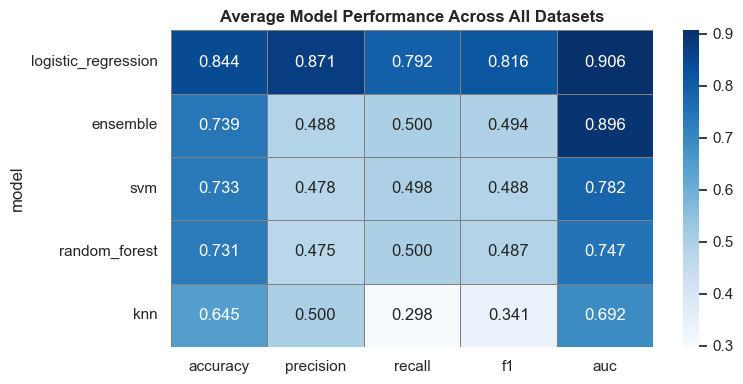

In [69]:
cross_results = pd.concat([scores_df, hcc1806_DS_results, mcf07_DS_results, mcf07_SS_results], ignore_index=True)
avg_metrics = cross_results.groupby('model')[['accuracy', 'precision', 'recall', 'f1', 'auc']].mean()
avg_metrics = avg_metrics.sort_values('f1', ascending=False).round(3)
plt.figure(figsize=(8, 4))
sns.heatmap(avg_metrics, annot=True, fmt='.3f', cmap='Blues',
            linewidths=0.5, linecolor='grey')
plt.title('Average Model Performance Across All Datasets', weight = "bold")
plt.tight_layout()
plt.show()

The Logistic Regression model can be considered the best-performing model because it achieved consistently strong results across all datasets. Importantly, it was the only model that did not completely collapse in performance when switching from SmartSeq to DropSeq data, maintaining meaningful precision, recall, F1-score, and AUC values. This suggests that simpler and more robust linear approaches such as Logistic Regression may generalize better across heterogeneous biological datasets and technical platforms than more complex models. Its strong performance combined with high interpretability also makes it particularly suitable for identifying hypoxia-related patterns in tumour cell gene expression data.

In [71]:
LR_summary = pd.concat([df[df["model"] == "logistic_regression"]for df in [scores_df, mcf07_SS_results, mcf07_DS_results, hcc1806_DS_results]], ignore_index=True)
LR_summary

,model,accuracy,precision,recall,f1,auc,confusion_matrix,dataset
0,logistic_regression,1.000000,1.000000,1.000000,1.000000,1.000000,"[[17, 0], [0, 20]]",HCC1806 SmartSeq (Internal)
1,logistic_regression,0.892000,0.821192,1.000000,0.901818,0.995648,"[[99, 27], [0, 124]]",MCF7 SmartSeq
2,logistic_regression,0.731619,0.802915,0.463065,0.587374,0.795792,"[[11691, 1014], [4790, 4131]]",MCF7 DropSeq
3,logistic_regression,0.751941,0.859330,0.706372,0.775379,0.833855,"[[4754, 1029], [2613, 6286]]",HCC1806 DropSeq


In [77]:
# saving model for pathway analysis in different notebook
dump(best_models["logistic_regression"][0], "/Users/bianca/Desktop/LR_model.joblib")

['/Users/bianca/Desktop/LR_model.joblib']

# **Testing on Unseen Data**

We proceed by testing our best-performing model, Logistic Regression, on unseen data. And saving its predictions. 

In [72]:
anonim = pd.read_csv("/Users/bianca/Desktop/HCC1806_SmartS_Filtered_Normalised_3000_Data_test_anonim.txt", delimiter="\ ",engine='python',index_col=0)
anonim = anonim.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in anonim.columns})
anonim = anonim.T
anonim = dataset.rename(columns={"{}".format(i):"{}".format(remove_double_quotes(i)) for i in anonim.columns})
anonim.head()

,DDIT4,ANGPTL4,CALML5,KRT14,CCNB1,IGFBP3,AKR1C2,KRT6A,NDRG1,KRT4,...,ZYG11A,NRG1,RBMS3,VCPIP1,LINC02693,OR8B9P,NEAT1,ZDHHC23,ODAD2,label
output.STAR.PCRPlate1G12_Normoxia_S32_Aligned.sortedByCoord.out.bam,0,48,0,321,298,82,6250,634,0,0,...,10,136,0,0,29,0,29,0,0,0
output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.sortedByCoord.out.bam,8739,2101,55,96,1824,1938,62,0,522,413,...,0,264,0,134,68,0,213,0,0,1
output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sortedByCoord.out.bam,13098,14032,0,0,1616,247,430,907,348,0,...,0,38,0,0,0,0,92,0,0,1
output.STAR.PCRPlate1G3_Hypoxia_S7_Aligned.sortedByCoord.out.bam,2880,356,0,6211,3,3430,79,1953,592,176,...,0,16,0,4,1,0,1,0,0,1
output.STAR.PCRPlate1G4_Hypoxia_S107_Aligned.sortedByCoord.out.bam,7777,5661,4383,0,145,4618,246,85,206,0,...,1,25,0,0,0,0,128,0,0,1


In [73]:
X_unseen = anonim[X_train.columns]
y_pred_unseen = best_models["logistic_regression"][0].predict(X_unseen)
y_prob_unseen = best_models["logistic_regression"][0].predict_proba(X_unseen)[:, 1]

predictions = pd.DataFrame({ "sample": X_unseen.index, "prediction": y_pred_unseen, "probability_hypoxia": y_prob_unseen})
predictions.to_csv('/Users/bianca/Desktop/predictions_HCC1806SmarSeq.csv')
predictions


,sample,prediction,probability_hypoxia
0,output.STAR.PCRPlate1G12_Normoxia_S32_Aligned....,0,9.364526e-07
1,output.STAR.PCRPlate1G1_Hypoxia_S102_Aligned.s...,1,9.999932e-01
2,output.STAR.PCRPlate1G2_Hypoxia_S2_Aligned.sor...,1,1.000000e+00
3,output.STAR.PCRPlate1G3_Hypoxia_S7_Aligned.sor...,1,9.996403e-01
4,output.STAR.PCRPlate1G4_Hypoxia_S107_Aligned.s...,1,1.000000e+00
...,...,...,...
177,output.STAR.PCRPlate4H10_Normoxia_S210_Aligned...,0,3.394330e-06
178,output.STAR.PCRPlate4H11_Normoxia_S214_Aligned...,0,2.676668e-06
179,output.STAR.PCRPlate4H2_Hypoxia_S199_Aligned.s...,1,9.999006e-01
180,output.STAR.PCRPlate4H7_Normoxia_S205_Aligned....,0,7.658992e-06
